# Measurement Error & Decision Risk
### A Monte Carlo Simulation Study Inspired by GRR Systems

Author: eng. Simeon Petkov  
Course: Math for Developers – Final Exam Project

## Abstract

In industrial testing environments, acceptance decisions are typically based on measured values compared against specification limits. However, every measurement system introduces variation, which may lead to incorrect decisions.

This project models both process variation and measurement system variation using probabilistic methods. A Monte Carlo simulation framework is developed to estimate the probability of false pass and false fail decisions under varying measurement conditions.

The objective is to quantify decision risk and analyze how measurement system quality influences product acceptance reliability.

## 1. Problem Definition

Consider a product characteristic measured during an End-of-Line (EOL) test.

A decision is made according to a lower specification limit (LSL).  
If the measured value is above the limit, the product is accepted; otherwise, it is rejected.

However, the measured value is not equal to the true value due to measurement system variation.

The central question of this study is:

> What is the probability of making an incorrect pass/fail decision due solely to measurement system error?

We aim to model this problem mathematically and estimate the associated decision risk using simulation techniques.

## 2. Mathematical Model

### 2.1 True Process Distribution

The true product characteristic is assumed to follow a normal distribution:

$$
X_{\text{true}} \sim \mathcal{N}(\mu_p, \sigma_p)
$$

where:

- \( \mu_p \) is the process mean  
- \( \sigma_p \) is the process standard deviation  

This represents the natural variation of the manufacturing process.

### 2.2 Measurement Error Model

The measurement system introduces random error:

$$
\varepsilon \sim \mathcal{N}(0, \sigma_m)
$$

The measured value is therefore:

$$
X_{\text{measured}} = X_{\text{true}} + \varepsilon
$$

where:

- \( \sigma_m \) is the measurement system standard deviation  
- \( \varepsilon \) represents random measurement noise  

This model assumes that the measurement error is unbiased and independent of the true value.

### 2.3 Decision Rule

Let \( LSL \) denote the lower specification limit.

The acceptance criterion is defined as:

$$
\text{Accept if } X_{\text{measured}} \geq LSL
$$

and

$$
\text{Reject if } X_{\text{measured}} < LSL
$$

The decision is therefore based on the measured value rather than the true value.

### 2.4 Decision Error Types

Because the decision is based on the measured value rather than the true value, incorrect decisions may occur.

Two types of decision errors are possible:

#### False Fail (Type I Decision Error)

A conforming product is rejected:

$$
X_{\text{true}} \geq LSL 
\quad \text{and} \quad 
X_{\text{measured}} < LSL
$$

#### False Pass (Type II Decision Error)

A nonconforming product is accepted:

$$
X_{\text{true}} < LSL 
\quad \text{and} \quad 
X_{\text{measured}} \geq LSL
$$

These probabilities quantify the risk introduced solely by measurement system variation.

### 2.5 Monte Carlo Estimation

Let \( N \) be the number of simulated products.

The probability of false fail is estimated as:

$$
\hat{P}_{FF} = \frac{n_{FF}}{N}
$$

where \( n_{FF} \) is the number of simulated cases for which:

$$
X_{\text{true}} \geq LSL \quad \text{and} \quad X_{\text{measured}} < LSL
$$

The probability of false pass is estimated as:

$$
\hat{P}_{FP} = \frac{n_{FP}}{N}
$$

where \( n_{FP} \) is the number of simulated cases for which:

$$
X_{\text{true}} < LSL \quad \text{and} \quad X_{\text{measured}} \geq LSL
$$

As \( N \) increases, these estimates converge to the true probabilities.

## 3. First Simulation Implementation (Monte Carlo)

This section implements the Monte Carlo estimation of false pass and false fail probabilities based on the mathematical model defined above.

In [17]:
import numpy as np

def simulate_decision_risk(
    mu_p: float,
    sigma_p: float,
    sigma_m: float,
    lsl: float,
    n: int = 100_000,
    seed: int = 42
) -> dict:
    """
    Monte Carlo simulation for decision risk under measurement error.

    Returns:
        dict with estimated false fail and false pass probabilities.
    """
    rng = np.random.default_rng(seed)

    # True values from process distribution
    x_true = rng.normal(loc=mu_p, scale=sigma_p, size=n)

    # Measurement error
    eps = rng.normal(loc=0.0, scale=sigma_m, size=n)

    # Measured values
    x_meas = x_true + eps

    # True condition (conforming vs nonconforming)
    true_conforming = x_true >= lsl
    true_nonconforming = ~true_conforming

    # Decision based on measured value
    decided_accept = x_meas >= lsl
    decided_reject = ~decided_accept

    # Errors
    false_fail = true_conforming & decided_reject
    false_pass = true_nonconforming & decided_accept

    p_ff = false_fail.mean()
    p_fp = false_pass.mean()

    return {
        "N": n,
        "mu_p": mu_p,
        "sigma_p": sigma_p,
        "sigma_m": sigma_m,
        "LSL": lsl,
        "P_false_fail": float(p_ff),
        "P_false_pass": float(p_fp),
    }

In [18]:
result = simulate_decision_risk(
    mu_p=10.0,
    sigma_p=1.0,
    sigma_m=0.5,
    lsl=8.0,
    n=200_000,
    seed=1
)
result

{'N': 200000,
 'mu_p': 10.0,
 'sigma_p': 1.0,
 'sigma_m': 0.5,
 'LSL': 8.0,
 'P_false_fail': 0.020275,
 'P_false_pass': 0.00624}

### 3.1 Initial Test Case

The first simulation run demonstrates that even when the process mean is above the specification limit, measurement noise can still produce a nonzero probability of false fail and false pass decisions.

### 3.2 Interpretation of the First Simulation

The simulation results indicate that measurement system variation can introduce a measurable level of decision risk.

In this example:

- The estimated probability of **false fail** is approximately **2%**.
- The estimated probability of **false pass** is approximately **0.6%**.

This means that even when the process is centered above the specification limit, measurement noise can still cause correct products to be rejected and nonconforming products to be accepted.

These results demonstrate the importance of controlling measurement system variation when making pass/fail decisions in industrial testing.

## 4. Validation Checks

This section verifies that the Monte Carlo simulation behaves consistently and produces logically valid results under controlled conditions.

In [22]:
# Validation Check 1: Output structure and probability range

test_result = simulate_decision_risk(
    mu_p=10.0,
    sigma_p=1.0,
    sigma_m=0.5,
    lsl=8.0,
    n=100_000,
    seed=123
)

print(test_result)

assert 0.0 <= test_result["P_false_fail"] <= 1.0
assert 0.0 <= test_result["P_false_pass"] <= 1.0

print("Validation Check 1 passed: probabilities are within [0, 1].")

{'N': 100000, 'mu_p': 10.0, 'sigma_p': 1.0, 'sigma_m': 0.5, 'LSL': 8.0, 'P_false_fail': 0.02056, 'P_false_pass': 0.00633}
Validation Check 1 passed: probabilities are within [0, 1].


In [23]:
# Validation Check 2: No measurement error should produce no decision risk

zero_error_result = simulate_decision_risk(
    mu_p=10.0,
    sigma_p=1.0,
    sigma_m=0.0,
    lsl=8.0,
    n=100_000,
    seed=123
)

print(zero_error_result)

assert zero_error_result["P_false_fail"] == 0.0
assert zero_error_result["P_false_pass"] == 0.0

print("Validation Check 2 passed: zero measurement error gives zero decision risk.")

{'N': 100000, 'mu_p': 10.0, 'sigma_p': 1.0, 'sigma_m': 0.0, 'LSL': 8.0, 'P_false_fail': 0.0, 'P_false_pass': 0.0}
Validation Check 2 passed: zero measurement error gives zero decision risk.


In [24]:
# Validation Check 3: Same seed should reproduce the same result

result_a = simulate_decision_risk(
    mu_p=10.0,
    sigma_p=1.0,
    sigma_m=0.5,
    lsl=8.0,
    n=100_000,
    seed=999
)

result_b = simulate_decision_risk(
    mu_p=10.0,
    sigma_p=1.0,
    sigma_m=0.5,
    lsl=8.0,
    n=100_000,
    seed=999
)

assert result_a["P_false_fail"] == result_b["P_false_fail"]
assert result_a["P_false_pass"] == result_b["P_false_pass"]

print("Validation Check 3 passed: identical seed gives identical simulation output.")

Validation Check 3 passed: identical seed gives identical simulation output.


In [25]:
# Validation Check 4: Higher measurement error should generally increase decision risk

low_noise = simulate_decision_risk(
    mu_p=10.0,
    sigma_p=1.0,
    sigma_m=0.2,
    lsl=8.0,
    n=100_000,
    seed=123
)

high_noise = simulate_decision_risk(
    mu_p=10.0,
    sigma_p=1.0,
    sigma_m=0.8,
    lsl=8.0,
    n=100_000,
    seed=123
)

print("Low noise:", low_noise)
print("High noise:", high_noise)

assert high_noise["P_false_fail"] >= low_noise["P_false_fail"]
assert high_noise["P_false_pass"] >= low_noise["P_false_pass"]

print("Validation Check 4 passed: larger measurement error increases decision risk.")

Low noise: {'N': 100000, 'mu_p': 10.0, 'sigma_p': 1.0, 'sigma_m': 0.2, 'LSL': 8.0, 'P_false_fail': 0.00578, 'P_false_pass': 0.00355}
High noise: {'N': 100000, 'mu_p': 10.0, 'sigma_p': 1.0, 'sigma_m': 0.8, 'LSL': 8.0, 'P_false_fail': 0.04414, 'P_false_pass': 0.00788}
Validation Check 4 passed: larger measurement error increases decision risk.


### 4.1 Validation Summary

The validation checks confirm that the simulation behaves as expected under controlled conditions.

The results show that:

- estimated probabilities remain within valid bounds;
- zero measurement error produces zero false decisions;
- repeated runs with the same random seed are reproducible;
- larger measurement variation leads to higher decision risk.

These checks support the correctness of the simulation model before proceeding to broader experiments and visualization.

## 5. Experiment: Decision Risk vs Measurement Error

This experiment evaluates how the probability of false fail and false pass decisions changes as the measurement system standard deviation increases.

The process parameters are kept constant, while the measurement error parameter \( \sigma_m \) is varied across a predefined range.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
sigma_m_values = np.arange(0.0, 1.1, 0.1)

results = []

for sigma_m in sigma_m_values:
    res = simulate_decision_risk(
        mu_p=10.0,
        sigma_p=1.0,
        sigma_m=float(sigma_m),
        lsl=8.0,
        n=200_000,
        seed=123
    )
    results.append(res)

df_results = pd.DataFrame(results)
df_results

,N,mu_p,sigma_p,sigma_m,LSL,P_false_fail,P_false_pass
0,200000,10.0,1.0,0.0,8.0,0.000000,0.000000
1,200000,10.0,1.0,0.1,8.0,0.002430,0.001810
2,200000,10.0,1.0,0.2,8.0,0.005745,0.003185
3,200000,10.0,1.0,0.3,8.0,0.009870,0.004240
4,200000,10.0,1.0,0.4,8.0,0.014645,0.005240
5,200000,10.0,1.0,0.5,8.0,0.020500,0.006030
6,200000,10.0,1.0,0.6,8.0,0.027175,0.006670
7,200000,10.0,1.0,0.7,8.0,0.035300,0.007205
8,200000,10.0,1.0,0.8,8.0,0.043840,0.007565
9,200000,10.0,1.0,0.9,8.0,0.053630,0.007945


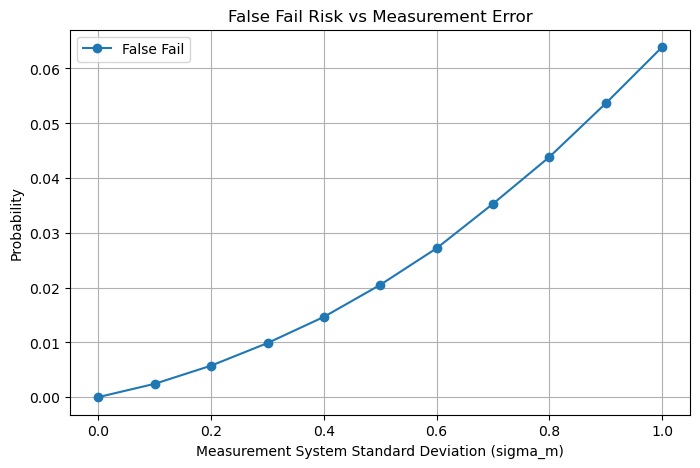

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["sigma_m"], df_results["P_false_fail"], marker="o", label="False Fail")
plt.xlabel("Measurement System Standard Deviation (sigma_m)")
plt.ylabel("Probability")
plt.title("False Fail Risk vs Measurement Error")
plt.grid(True)
plt.legend()
plt.show()

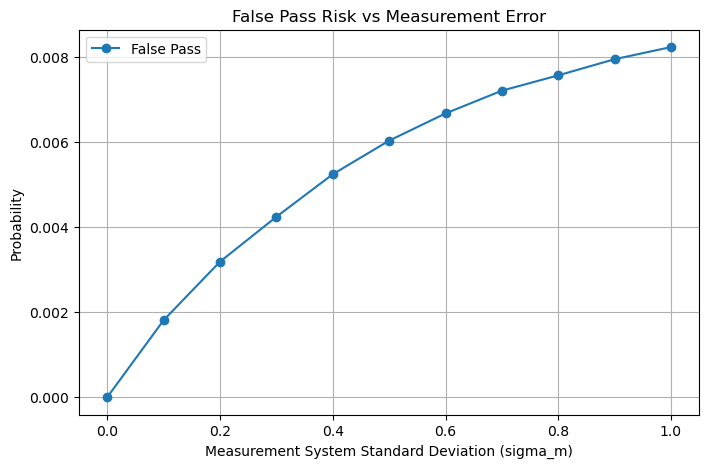

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["sigma_m"], df_results["P_false_pass"], marker="o", label="False Pass")
plt.xlabel("Measurement System Standard Deviation (sigma_m)")
plt.ylabel("Probability")
plt.title("False Pass Risk vs Measurement Error")
plt.grid(True)
plt.legend()
plt.show()

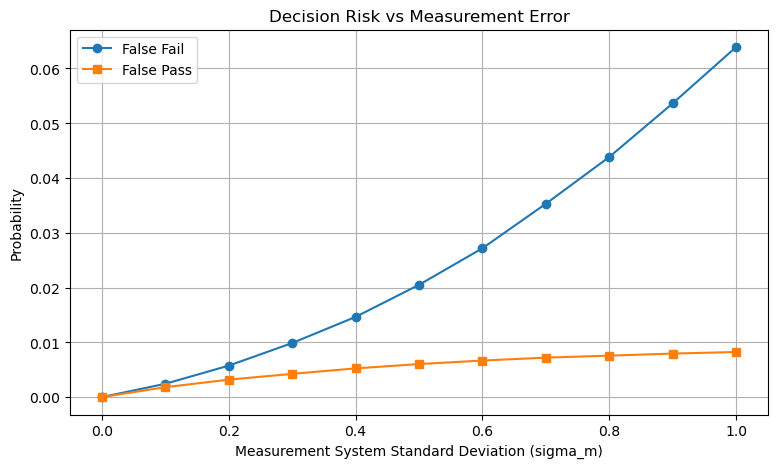

In [42]:
plt.figure(figsize=(9, 5))
plt.plot(df_results["sigma_m"], df_results["P_false_fail"], marker="o", label="False Fail")
plt.plot(df_results["sigma_m"], df_results["P_false_pass"], marker="s", label="False Pass")
plt.xlabel("Measurement System Standard Deviation (sigma_m)")
plt.ylabel("Probability")
plt.title("Decision Risk vs Measurement Error")
plt.grid(True)
plt.legend()
plt.show()

### 5.1 Interpretation of Experimental Results

The results show that decision risk increases as measurement system variation increases.

Both false fail and false pass probabilities rise with increasing \( \sigma_m \), confirming that measurement uncertainty directly affects the reliability of pass/fail decisions.

This behavior is consistent with the theoretical expectation that noisier measurement systems lead to greater overlap around the specification boundary and therefore more classification errors.